In [1]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG19, MobileNetV2, Xception
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, accuracy_score

In [2]:
path = "F:/Office/Project2026/PlantDiseaseTransformer/"
train_dir = path+"Dataset/train"
test_dir = path+"Dataset/test"
IMG_SIZE = (224,224)
BATCH_SIZE = 32
EPOCHS = 10

In [3]:
#Data Preprocessing
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

num_classes = len(train_generator.class_indices)
print(num_classes)

Found 4745 images belonging to 4 classes.
Found 595 images belonging to 4 classes.
4


In [4]:
#Model Builder Function
def build_model(base_model):

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    predictions = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=predictions)

    model.compile(
        optimizer=Adam(learning_rate=0.0001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [6]:
#Train Xception Model
base_xception = Xception(weights='imagenet', include_top=False, input_shape=(224,224,3))

for layer in base_xception.layers:
    layer.trainable = False

model_xception = build_model(base_xception)

history_xception = model_xception.fit(
    train_generator,
    validation_data=test_generator,
    epochs=EPOCHS
)

model_xception.save(path+"model/Xception_rice_disease.h5")

83683744/83683744 [==============================] - 32s 0us/step
Epoch 1/10


149/149 [==============================] - 1010s 7s/step - loss: 0.7408 - accuracy: 0.7252 - val_loss: 0.4020 - val_accuracy: 0.8756
Epoch 2/10
149/149 [==============================] - 877s 6s/step - loss: 0.3971 - accuracy: 0.8577 - val_loss: 0.2712 - val_accuracy: 0.9244
Epoch 3/10
149/149 [==============================] - 898s 6s/step - loss: 0.3039 - accuracy: 0.8946 - val_loss: 0.2086 - val_accuracy: 0.9429
Epoch 4/10
149/149 [==============================] - 892s 6s/step - loss: 0.2415 - accuracy: 0.9212 - val_loss: 0.1753 - val_accuracy: 0.9546
Epoch 5/10
149/149 [==============================] - 788s 5s/step - loss: 0.2191 - accuracy: 0.9248 - val_loss: 0.1548 - val_accuracy: 0.9546
Epoch 6/10
149/149 [==============================] - 789s 5s/step - loss: 0.1888 - accuracy: 0.9399 - val_loss: 0.1423 - val_accuracy: 0.9647
Epoch 7/10
149/149 [==============================] - 824s 6s/step - loss

C:\Program Files\Anaconda3\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [10]:
def evaluate_model(model):

    predictions = model.predict(test_generator)
    y_pred = np.argmax(predictions, axis=1)
    y_true = test_generator.classes

    acc = accuracy_score(y_true, y_pred)

    report = classification_report(
        y_true,
        y_pred,
        target_names=list(test_generator.class_indices.keys())
    )

    return acc, report


19/19 [==============================] - 85s 4s/step
Xception Accuracy: 0.9747899159663865
                      precision    recall  f1-score   support

Rice_Bacterialblight       0.98      0.96      0.97       159
          Rice_Blast       0.95      0.98      0.96       144
      Rice_Brownspot       0.97      0.97      0.97       160
         Rice_Tungro       1.00      0.99      1.00       132

            accuracy                           0.97       595
           macro avg       0.98      0.98      0.98       595
        weighted avg       0.98      0.97      0.97       595



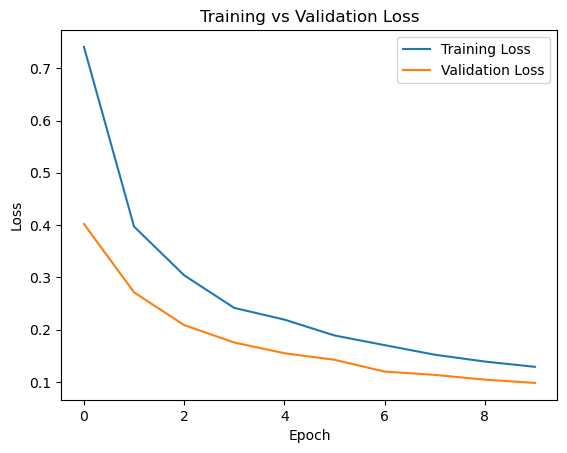

In [13]:
xcep_acc, xcep_report = evaluate_model(model_xception)
print("Xception Accuracy:", xcep_acc)
print(xcep_report)

plt.plot(history_xception.history['loss'], label='Training Loss')
plt.plot(history_xception.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()

plt.show()